In [ ]:
class ToolStrategy(Generic[SchemaT]):
    schema: type[SchemaT]
    tool_message_content: str | None
    handle_errors: Union[bool, str, type[Exception], tuple[type[Exception],
    ...], Callable[[Exception], str]]

schema（必需参数）：与提供商策略的schema参数功能一致，支持Pydantic模型、
TypedDict、JSON Schema、数据类(@dataclass)，同时还支持联合类型Union[类型1, 类型
2]（允许模型根据输入内容选择最匹配的数据结构）。
tool_message_content（可选参数）：用于自定义生成结构化输出时，会话历史中记录的提示信
息。默认使用展示输出数据的标准响应语句。
handle_errors（可选参数）：用于指定数据校验失败时的重试策略，默认值为True。

结构化输出：schema参数
下面演示四种Schema进行结构化输出代码实现。
提前说明：因为涉及到不同的Schema在不同模型供应商下表现的支持力度不同（上一章有说明，这里
提供了两个模型供应商，大家自己选择）

输出模式1：Pydantic类型
Pydantic类型的Schema支持数据验证，是优先推荐使用的方式。
举例1：

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}}  #关闭思考模式
)


In [6]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import ToolStrategy
from langchain.agents import create_agent
from langchain.messages import HumanMessage


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


agent = create_agent(
    model=model,
    response_format=ToolStrategy(ContactInfo)
)
response = agent.invoke({
    "messages": [
        HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：songhk@atguigu.com，手机号：12345678912")
    ]
}
)
for msg in response["messages"]:
    msg.pretty_print()
# print(response["structured_response"])

================================ Human Message =================================

从这段话中抽取结构化信息：小明的邮箱地址为：songhk@atguigu.com，手机号：12345678912
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_00_Zdphv675Sm0072UYTvtp6117)
 Call ID: call_00_Zdphv675Sm0072UYTvtp6117
  Args:
    name: 小明
    email: songhk@atguigu.com
    phone: 12345678912
================================= Tool Message =================================
Name: ContactInfo

Returning structured response: name='小明' email='songhk@atguigu.com' phone='12345678912'


观察日志可知，这种方式将结构化信息作为
伪工具传递，显然使用了Function Calling方法。

举例2：

In [10]:
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from rich import print as rprint


# 定义工具
@tool(parse_docstring=True)
def search_customer_database(query: str) -> str:
    """
    在客户数据库中搜索信息

    Args:
        query (str): 客户查询字符串，例如 "张三" 或 "李四"

    Returns:
        str: 客户记录字符串，包含客户姓名、等级、最近购买日期和累计消费
    """
    # 模拟数据库查询结果
    if "张三" in query.lower():
        return "客户记录：张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000"
    elif "李四" in query.lower():
        return "客户记录：李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200"
    else:
        return f"关于客户{query}，无记录"


@tool(parse_docstring=True)
def send_email(customer: str) -> str:
    """
    发送感谢邮件

    Args:
        customer (str): 客户名称，例如 "张三" 或 "李四"

    Returns:
        str: 确认消息，包含已发送的客户名称
     """
    return f"已向 {customer} 发送感谢邮件"


# 定义Pydantic Schema
class CustomerAnalysis(BaseModel):
    """客户分析报告"""
    customer_name: str = Field(None, description="客户姓名")
    customer_tier: Literal["潜在客户", "普通客户", "VIP客户", "流失风险"] = Field("潜在客户",
                                                                                  description="客户等级,只能是潜在客户、普通客户、VIP客户或流失风险")
    recent_activity: str = Field(None, description="最近活动")
    spending_level: Literal["低", "中", "高"] = Field(None, description="消费水平")
    send_email: bool = Field(False, description="是否已发送感谢邮件")


# 创建智能体
agent = create_agent(
    model=model,
    system_prompt=SystemMessage(content=""
                                        "请分析指定客户的情况："
                                        "1. 先搜索客户数据库了解最新情况 "
                                        "2. 如果是VIP客户，则发送感谢邮件 "
                                        "3. 基于搜索结果生成结构化分析报告 "
                                        "4. 如果用户提问与客户记录无关或找不到客户信息，则返回空对象，不发送感谢邮件"
                                ),
    tools=[search_customer_database, send_email],
    response_format=ToolStrategy(CustomerAnalysis)
)
# 执行分析
result = agent.invoke({
    "messages": [{"role": "user", "content": "请分析客户张三"}]
    # "messages": [{"role": "user","content": "请分析客户李四"}]
    # "messages": [{"role": "user","content": "请分析客户王五"}]
    # "messages": [{"role": "user","content": "今天天气如何"}]
})
# 处理结果
rprint(result)
if "structured_response" in result:
    analysis = result["structured_response"]
print(analysis)

{
    'messages': [
        HumanMessage(
            content='请分析客户张三',
            additional_kwargs={},
            response_metadata={},
            id='a6023423-f45a-4981-acf3-aaaea3d6dc56'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 39,
                    'prompt_tokens': 622,
                    'total_tokens': 661,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 622
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '4be35f1a-ff11-43c2-8eae-b09ccd215377',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f6618-94a8-7663-a32d-ed7554dcc948-0',
            tool_calls=[
                {
                    'name': 'search_customer_database',
                    'args': {'query': '张三'},
                    'id': 'call_00_twNn65dIK3HOZPMzpKQJ1432',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 622,
                'output_tokens': 39,
                'total_tokens': 661,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='客户记录：张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000',
            name='search_customer_database',
            id='f365dab2-7064-483d-b418-17a3076d32ea',
            tool_call_id='call_00_twNn65dIK3HOZPMzpKQJ1432'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 36,
                    'prompt_tokens': 706,
                    'total_tokens': 742,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 640},
                    'prompt_cache_hit_tokens': 640,
                    'prompt_cache_miss_tokens': 66
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '23c32cc7-c264-4e3b-b0f8-5b18c7967abe',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f6618-9903-7fb1-81f3-7698f240d296-0',
            tool_calls=[
                {
                    'name': 'send_email',
                    'args': {'customer': '张三'},
                    'id': 'call_00_hpuWQn3x9Pde4vuiUt960405',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 706,
                'output_tokens': 36,
                'total_tokens': 742,
                'input_token_details': {'cache_read': 640},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='已向 张三 发送感谢邮件',
            name='send_email',
            id='7b1c47b4-36ff-4e00-9c83-04070646053f',
            tool_call_id='call_00_hpuWQn3x9Pde4vuiUt960405'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 119,
                    'prompt_tokens': 769,
             

customer_name='张三' customer_tier='VIP客户' recent_activity='最近购买日期：2026-01-15' spending_level='高' send_email=True


注意：
1. 如果是结构化输出，在系统提示词中最后提示结构化输出结果，如果提示词中先结构化输出结果
（Agent已经执行完成），可能会导致一些工具不会再被调用。
2. 系统提示词中最后加入“未找到用户”时的处理提示，避免程序一直调用工具尝试查找对应用户信
息。

输出模式2：TypedDict类型
TypedDict 允许为字典对象定义固定的键名和对应的
值类型，是
带有类型提示的字典结构。具体的：
1. TypedDict字段定义采用 Annotated[类型, 默认值, "描述"]格式
2. 可选字段使用 Optional包装，默认值在 Annotated 中指定
3. TypedDict 不支持运行时验证。

In [3]:
from typing import Optional, Literal, Annotated
from pydantic import BaseModel, Field
from langchain.agents.structured_output import ToolStrategy
from langchain.agents import create_agent
from langchain.messages import HumanMessage


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: Annotated[str, ..., "用户姓名"]
    email: Annotated[str, ..., "用户邮箱地址"]
    phone: Annotated[str, ..., "用户的手机号"]


agent = create_agent(
    model=model,
    response_format=ToolStrategy(ContactInfo)
)
response = agent.invoke({
    "messages": [
        HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：songhk@atguigu.com，手机号：12345678912")
    ]
}
)
for msg in response["messages"]:
    msg.pretty_print()
# print(response["structured_response"])

================================ Human Message =================================

从这段话中抽取结构化信息：小明的邮箱地址为：songhk@atguigu.com，手机号：12345678912
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_00_9lL9po1XecjbPkXRwODC9781)
 Call ID: call_00_9lL9po1XecjbPkXRwODC9781
  Args:
    name: 小明
    email: songhk@atguigu.com
    phone: 12345678912
================================= Tool Message =================================
Name: ContactInfo

Returning structured response: name='小明' email='songhk@atguigu.com' phone='12345678912'


In [4]:
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.tools import tool
from rich import print as rprint


# 定义工具
@tool(parse_docstring=True)
def search_customer_database(query: str) -> str:
    """
    在客户数据库中搜索信息

    Args:
        query (str): 客户查询字符串，例如 "张三" 或 "李四"

    Returns:
        str: 客户记录字符串，包含客户姓名、等级、最近购买日期和累计消费
    """
    # 模拟数据库查询结果
    if "张三" in query.lower():
        return "客户记录：张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000"
    elif "李四" in query.lower():
        return "客户记录：李四，普通客户，最近购买日期：2025-12-20，累计消费：$3,200"
    else:
        return f"关于客户{query}，无记录"


@tool(parse_docstring=True)
def send_email(customer: str) -> str:
    """
    发送感谢邮件

    Args:
        customer (str): 客户名称，例如 "张三" 或 "李四"

    Returns:
        str: 确认消息，包含已发送的客户名称
     """
    return f"已向 {customer} 发送感谢邮件"


# 定义Pydantic Schema
class CustomerAnalysis(BaseModel):
    """客户分析报告"""
    customer_name: Annotated[str, ..., "客户姓名"]
    customer_tier: Annotated[Literal["潜在客户", "普通客户", "VIP客户", "流失风险"], ..., "客户等级"]
    recent_activity: Annotated[str, ..., "客户最近活动"]
    spending_level: Annotated[Literal["低", "中", "高"], ..., "消费水平"]
    send_email: Annotated[bool, ..., "是否已发送感谢邮件"]


# 创建智能体
agent = create_agent(
    model=model,
    system_prompt=SystemMessage(content=""
                                        "请分析指定客户的情况："
                                        "1. 先搜索客户数据库了解最新情况 "
                                        "2. 如果是VIP客户，则发送感谢邮件 "
                                        "3. 基于搜索结果生成结构化分析报告 "
                                        "4. 如果用户提问与客户记录无关或找不到客户信息，则返回空对象，不发送感谢邮件"
                                ),
    tools=[search_customer_database, send_email],
    response_format=ToolStrategy(CustomerAnalysis)
)
# 执行分析
result = agent.invoke({
    "messages": [{"role": "user", "content": "请分析客户张三"}]
    # "messages": [{"role": "user","content": "请分析客户李四"}]
    # "messages": [{"role": "user","content": "请分析客户王五"}]
    # "messages": [{"role": "user","content": "今天天气如何"}]
})
# 处理结果
rprint(result)
if "structured_response" in result:
    analysis = result["structured_response"]
print(analysis)

{
    'messages': [
        HumanMessage(
            content='请分析客户张三',
            additional_kwargs={},
            response_metadata={},
            id='4b72550b-eff4-4cc2-9cd1-fa982166e0e1'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 39,
                    'prompt_tokens': 571,
                    'total_tokens': 610,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 315
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '85036932-567f-499f-bf78-51b19894a074',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69b6-2b4b-7540-847a-2666d0dbbe70-0',
            tool_calls=[
                {
                    'name': 'search_customer_database',
                    'args': {'query': '张三'},
                    'id': 'call_00_jSDhHM39Gti0nysKvVFC6999',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 571,
                'output_tokens': 39,
                'total_tokens': 610,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='客户记录：张三，VIP客户，最近购买日期：2026-01-15，累计消费：$15,000',
            name='search_customer_database',
            id='b44a8fee-913f-48b0-8fff-2e8e238abac1',
            tool_call_id='call_00_jSDhHM39Gti0nysKvVFC6999'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 36,
                    'prompt_tokens': 655,
                    'total_tokens': 691,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                    'prompt_cache_hit_tokens': 512,
                    'prompt_cache_miss_tokens': 143
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '280be980-4b00-4659-a41d-05b42fd45ed9',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69b6-307e-7431-ad21-56465dd58126-0',
            tool_calls=[
                {
                    'name': 'send_email',
                    'args': {'customer': '张三'},
                    'id': 'call_00_pgJicYKa7jPIyDATAt9h5014',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 655,
                'output_tokens': 36,
                'total_tokens': 691,
                'input_token_details': {'cache_read': 512},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='已向 张三 发送感谢邮件',
            name='send_email',
            id='5d75801d-a8e5-4d65-853c-b770ee57d6ac',
            tool_call_id='call_00_pgJicYKa7jPIyDATAt9h5014'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 119,
                    'prompt_tokens': 718,
      

customer_name='张三' customer_tier='VIP客户' recent_activity='最近购买日期：2026-01-15' spending_level='高' send_email=True


输出模式3：JsonSchema类型
JSON Schema是提供一个标准的 JSON Schema 字典来定义结构。适合需要与多种编程语言交互或进行
复杂数据约束定义的场景。
举例1：

In [5]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage

json_schema = {
    "title": "ContactInfo",
    "description": "用户的联系方式",
    "type": "object",
    "properties": {
        "name": {"description": "用户姓名",
                 "type": "string"
                 },
        "email": {
            "description": "用户邮箱地址",
            "type": "string"
        },
        "phone": {
            "description": "用户的手机号",
            "type": "string"
        }
    },
    "required": [
        "name",
        "email",
        "phone"
    ]
}
agent = create_agent(
    model=model,
    response_format=ToolStrategy(json_schema)
)
response = agent.invoke(
    {
        "messages": [
            HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：songhk @ atguigu.com，手机号：12345678912")]
    }
)
for msg in response["messages"]:
    msg.pretty_print()
    # print(response["structured_response"])

================================ Human Message =================================

从这段话中抽取结构化信息：小明的邮箱地址为：songhk @ atguigu.com，手机号：12345678912
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_00_R81miGHKgukuNqEoIZmy5338)
 Call ID: call_00_R81miGHKgukuNqEoIZmy5338
  Args:
    name: 小明
    email: songhk@atguigu.com
    phone: 12345678912
================================= Tool Message =================================
Name: ContactInfo

Returning structured response: {'name': '小明', 'email': 'songhk@atguigu.com', 'phone': '12345678912'}


输出模式4：@dataclass类型
@dataclass是Python 3.7引入的一个装饰器，用于简化数据存储类的定义。
举例1：

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.messages import HumanMessage


@dataclass
class ContactInfo:
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


agent = create_agent(
    model=model,
    response_format=ToolStrategy(ContactInfo)
)
response = agent.invoke(
    {
        "messages": [
            HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：songhk@atguigu.com，手机号：12345678912")
        ]
    }
)
for msg in response["messages"]:
    msg.pretty_print()
# print(response["structured_response"])

多schema联合模式
ToolStrategy允许指定多个类型“Union[类型1, 类型2] ”这种写法，LLM能够根据输入文本的内容，智能
地选择最合适的一个数据模型（Schema）来生成结构化输出，但是最终会只有一种类型输出。
适用于根据不同输入内容，生成不同的结构化输出的场景，但是底层工具转换结构化输出只会转换成一
种结构化类型输出。

In [6]:
from pydantic import BaseModel, Field
from typing import Union
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.messages import HumanMessage


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


class EventInfo(BaseModel):
    """事件详情"""
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")


agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EventInfo]
    )
)
response = agent.invoke(
    {
        "messages": [
            HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：shkstart@atguigu.com，手机号：12345678912")
        ]
    }
)
for msg in response["messages"]:
    msg.pretty_print()
print(response["structured_response"])

================================ Human Message =================================

从这段话中抽取结构化信息：小明的邮箱地址为：shkstart@atguigu.com，手机号：12345678912
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_00_0bjdOO0slqA63tbvT2Wx3765)
 Call ID: call_00_0bjdOO0slqA63tbvT2Wx3765
  Args:
    name: 小明
    email: shkstart@atguigu.com
    phone: 12345678912
================================= Tool Message =================================
Name: ContactInfo

Returning structured response: name='小明' email='shkstart@atguigu.com' phone='12345678912'
name='小明' email='shkstart@atguigu.com' phone='12345678912'


In [7]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage("从这段话中抽取结构化信息：2026年高考报名人数突破1200万")
        ]
    }
)
for msg in response["messages"]:
    msg.pretty_print()
print(response["structured_response"])

================================ Human Message =================================

从这段话中抽取结构化信息：2026年高考报名人数突破1200万
================================== Ai Message ==================================
Tool Calls:
  EventInfo (call_00_niHiOJsQhC4o5KFqB1le7810)
 Call ID: call_00_niHiOJsQhC4o5KFqB1le7810
  Args:
    event_name: 高考报名
    date: 2026年
================================= Tool Message =================================
Name: EventInfo

Returning structured response: event_name='高考报名' date='2026年'
event_name='高考报名' date='2026年'


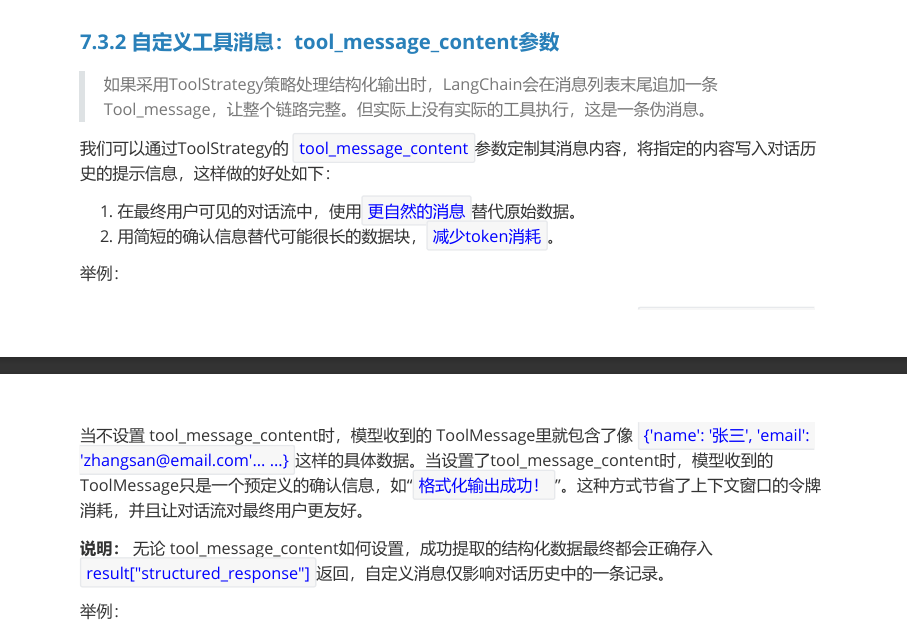

In [8]:
from pydantic import BaseModel, Field
from langchain.agents.structured_output import ToolStrategy
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from rich import print as rprint


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


# 自定义tool_message_content
agent = create_agent(
    model=model,
    response_format=ToolStrategy(schema=ContactInfo, tool_message_content="成功抽取结构化信息")
)
response = agent.invoke({
    "messages": [
        HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：songhk @ atguigu.com，手机号：12345678912")
    ]
}
)
rprint(response)

{
    'messages': [
        HumanMessage(
            content='从这段话中抽取结构化信息：小明的邮箱地址为：songhk @ atguigu.com，手机号：12345678912',
            additional_kwargs={},
            response_metadata={},
            id='4ef99006-8d1d-4a89-acb2-50add11ab5a0'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 77,
                    'prompt_tokens': 350,
                    'total_tokens': 427,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 94
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '0a09179b-52ae-46d2-984e-9eadb07ec204',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69c0-d625-7883-8f10-9183a88375f3-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '小明', 'email': 'songhk@atguigu.com', 'phone': '12345678912'},
                    'id': 'call_00_S2TKPoihAlF3EQunU3me3724',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 350,
                'output_tokens': 77,
                'total_tokens': 427,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='成功抽取结构化信息',
            name='ContactInfo',
            id='bc512ea6-b57d-45d4-9969-92945696a0ef',
            tool_call_id='call_00_S2TKPoihAlF3EQunU3me3724'
        )
    ],
    'structured_response': ContactInfo(name='小明', email='songhk@atguigu.com', phone='12345678912')
}